# Deep Computer Vision Using Convolutional Neural Networks

## Implementing Convolutional Layers with Keras

In [2]:
from sklearn.datasets import load_sample_images
import tensorflow as tf

images = load_sample_images()["images"]
images = tf.keras.layers.CenterCrop(height=70, width=120)(images)
images = tf.keras.layers.Rescaling(scale=1/255)(images)

In [3]:
images.shape

TensorShape([2, 70, 120, 3])

In [4]:
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7) # or Convolution2D
fmaps = conv_layer(images)

In [5]:
fmaps.shape

TensorShape([2, 64, 114, 32])

In [6]:
 conv_layer.kernel.shape

TensorShape([7, 7, 3, 32])

In [7]:
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7,
                                    padding="same")
fmaps = conv_layer(images)
fmaps.shape

TensorShape([2, 70, 120, 32])

In [8]:
kernels, biases = conv_layer.get_weights() # numpy arrays, .weights attributes gives TF variables
kernels.shape

(7, 7, 3, 32)

In [9]:
biases.shape

(32,)

## Implementing Pooling Layers with Keras

In [10]:
max_pool = tf.keras.layers.MaxPool2D(pool_size=2) # or MaxPooling2D

Depthwise max pooling layer:

In [11]:
class DepthPool(tf.keras.layers.Layer):
    def __init__(self, pool_size=2, **kwargs):
        super().__init__(**kwargs)
        self.pool_size = pool_size

    def call(self, inputs):
        shape = tf.shape(inputs) # shape[-1] is the number of channels
        groups = shape[-1] // self.pool_size # number of channel groups
        new_shape = tf.concat([shape[:-1], [groups, self.pool_size]], axis=0)
        return tf.reduce_max(tf.reshape(inputs, new_shape), axis=-1)

One last type of ppoling layer that you will often see in modern architectures is the global average pooling layer:

In [12]:
global_avg_pool = tf.keras.layers.GlobalAvgPool2D()
# Equivalent to:
global_avg_pool = tf.keras.layers.Lambda(
    lambda X: tf.reduce_mean(X, axis=[1, 2]))

In [13]:
global_avg_pool(images)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[0.643388  , 0.59718215, 0.5825038 ],
       [0.7630747 , 0.26010972, 0.10848834]], dtype=float32)>

## CNN Architectures

In [14]:
# Basic CNN to tackle the Fashion MNIST dataset
from functools import partial

DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, padding="same",
                        activation="relu", kernel_initializer="he_normal")
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[28, 28, 1]),
    DefaultConv2D(filters=64, kernel_size=7),
    tf.keras.layers.MaxPool2D(),
    DefaultConv2D(filters=128),
    DefaultConv2D(filters=128),
    tf.keras.layers.MaxPool2D(),
    DefaultConv2D(filters=256),
    DefaultConv2D(filters=256),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=10, activation="softmax")
])

## Implementing a ResNet-34 CNN Using Keras

Create a ResidualUnit layer:

In [15]:
DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, strides=1,
                        padding="same", kernel_initializer="he_normal", use_bias=False)

class ResidualUnit(tf.keras.layers.Layer):
    def __init__(self, filters, strides=1, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.activation = tf.keras.activations.get(activation)
        self.main_layers = [
        DefaultConv2D(filters, strides=strides),
        tf.keras.layers.BatchNormalization(),
        self.activation,
        DefaultConv2D(filters),
        tf.keras.layers.BatchNormalization()
        ]
        self.skip_layers = []
        if strides > 1:
            self.skip_layers = [
                DefaultConv2D(filters, kernel_size=1, strides=strides),
                tf.keras.layers.BatchNormalization()
            ]

    def call(self, inputs):
        Z = inputs
        for layer in self.main_layers:
            Z = layer(Z)
        skip_Z = inputs
        for layer in self.skip_layers:
            skip_Z = layer(skip_Z)
        return self.activation(Z + skip_Z)

In [16]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[224, 224, 3]),
    DefaultConv2D(64, kernel_size=7, strides=2, padding="same"),
])
prev_filters = 64

for filters in [64] * 3 + [128] * 4 + [256] * 6 + [512] * 3:
    strides = 1 if filters == prev_filters else 2
    model.add(ResidualUnit(filters, strides=strides))
    prev_filters = filters

model.add(tf.keras.layers.GlobalAvgPool2D())
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(10, activation="softmax"))

## Using Pretrained Models from Keras

In [17]:
model = tf.keras.applications.ResNet50(weights="imagenet")

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [18]:
images = load_sample_images()["images"]
images_resized = tf.keras.layers.Resizing(height=224, width=224,
                                          crop_to_aspect_ratio=True)(images)

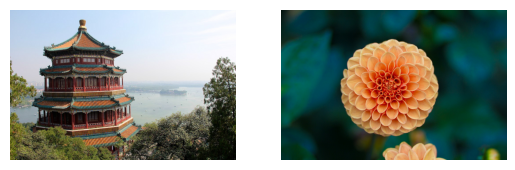

In [19]:
import matplotlib.pyplot as plt

for i, img in enumerate(images):
    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [20]:
inputs = tf.keras.applications.resnet50.preprocess_input(images_resized)

In [21]:
Y_proba = model.predict(inputs)
Y_proba.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


(2, 1000)

In [22]:
top_K = tf.keras.applications.resnet50.decode_predictions(Y_proba, top=3)
for image_index in range(len(images)):
    print(f"Image #{image_index}")
    for class_id, name, y_proba in top_K[image_index]:
        print(f"  {class_id} - {name:12s} {y_proba:.2%}")

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Image #0
  n03598930 - jigsaw_puzzle 30.60%
  n02782093 - balloon      17.20%
  n03888257 - parachute    5.59%
Image #1
  n04209133 - shower_cap   34.34%
  n09229709 - bubble       11.43%
  n02782093 - balloon      9.46%


## Pretrained Models for Transfer Learning

In [23]:
import tensorflow_datasets as tfds

dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)
dataset_size = info.splits["train"].num_examples # 3670
class_names = info.features["label"].names # ["dandelion", "daisy", ...]
n_classes = info.features["label"].num_classes # 5

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.3TIY2J_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [24]:
# There is only a train dataset, call tfds again
test_set_raw, valid_set_raw, train_set_raw = tfds.load(
    "tf_flowers",
    split=["train[:10%]", "train[10%:25%]", "train[25%:]"],
    as_supervised=True)

In [25]:
batch_size = 32
preprocess = tf.keras.Sequential([
    tf.keras.layers.Resizing(height=224, width=224, crop_to_aspect_ratio=True),
    tf.keras.layers.Lambda(tf.keras.applications.xception.preprocess_input)
])
train_set = train_set_raw.map(lambda X, y: (preprocess(X),  y))
train_set = train_set.shuffle(1000, seed=42).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)
test_set = test_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)

In [26]:
# create data augmentation model
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)
])

Try running the follwoing cell multiple times to see different random data augmentations:

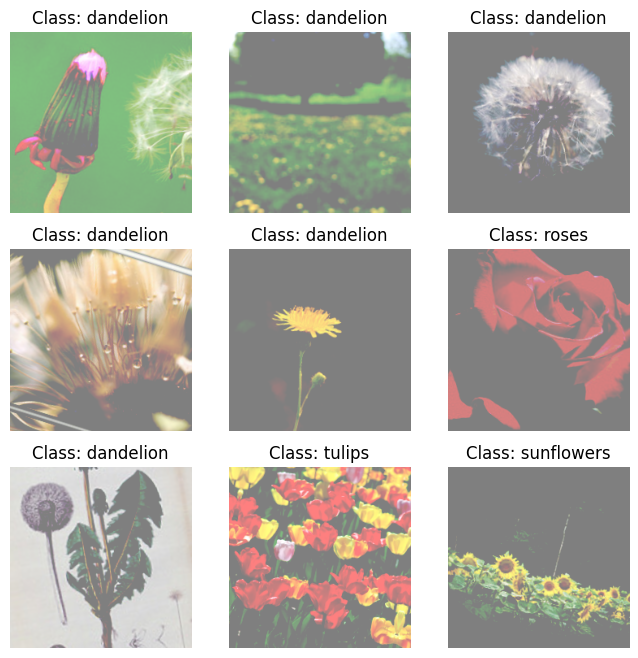

In [27]:
import numpy as np

plt.figure(figsize=(8, 8))
for X_batch, y_batch in valid_set.take(1):
    X_batch_augmented = data_augmentation(X_batch, training=True)
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        # We must rescale the images to the 0-1 range for imshow(), and also
        # clip the result to that range, because data augmentation may
        # make some values go out of bounds (e.g., RandomContrast in this case).
        plt.imshow(np.clip((X_batch_augmented[index] + 1) / 2, 0, 1))
        plt.title(f"Class: {class_names[y_batch[index]]}")
        plt.axis("off")

plt.show()


load the pretrained model, without its top layers, and replace them with our own, for the flower classification task:

In [28]:
base_model = tf.keras.applications.xception.Xception(weights="imagenet",
                                                     include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)
model = tf.keras.Model(inputs=base_model.input, outputs=output)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


It is usually a good idea to freeze the weights of the pretrained layers, at least at the beginning of training:

In [29]:
for layer in base_model.layers:
    layer.trainable = False

`Warning: Since the model uses the base model's layers directly, rather than the base_model object itself, setting base_model.trainable=False would have no affect`

Compile and train model:

In [30]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=3)

Epoch 1/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 51s 271ms/step - accuracy: 0.6993 - loss: 1.0258 - val_accuracy: 0.8258 - val_loss: 0.6265
Epoch 2/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9223 - loss: 0.2954 - val_accuracy: 0.8675 - val_loss: 0.6366
Epoch 3/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9307 - loss: 0.2316 - val_accuracy: 0.8711 - val_loss: 0.5696


After training the model for a few epochs, its validation accuracy should reach a bit over 80% and the stop improving. This means that the top layers are now pretty well trained, and we are ready to unfreeze some of the base model's top layers, then continue training. For example, let's unfreeze layers 56 and above(that's the start of the residual unit 7 out of 14, as you can see if you list the layer names):

In [31]:
for layer in base_model.layers[56:]:
    layer.trainable = True

Don't forget to compile the model whenever you freeze or unfreeze layers. Also make sure to use a much lower learning rate to avoid damaging the pretrained weights:

In [32]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 34s 133ms/step - accuracy: 0.8651 - loss: 0.3755 - val_accuracy: 0.8893 - val_loss: 0.5344
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9864 - loss: 0.0501 - val_accuracy: 0.9093 - val_loss: 0.2970
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9945 - loss: 0.0149 - val_accuracy: 0.9093 - val_loss: 0.2892
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9986 - loss: 0.0066 - val_accuracy: 0.9111 - val_loss: 0.3049
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9992 - loss: 0.0054 - val_accuracy: 0.9038 - val_loss: 0.3260
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9968 - loss: 0.0110 - val_accuracy: 0.9002 - val_loss: 0.3744
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9962 - loss: 0.0136 - val_accuracy: 0.9111 - val_loss: 0.3192
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9992 - loss: 0.0041 - val_accuracy: 0.9201 -

## Classification and Localization

In [33]:
base_model = tf.keras.applications.xception.Xception(weights="imagenet",
                                                     include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
class_output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)
loc_output = tf.keras.layers.Dense(4)(avg)
model = tf.keras.Model(inputs=base_model.input,
                       outputs=[class_output, loc_output])
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss=["sparse_categorical_crossentropy", "mse"],
              loss_weights=[0.8, 0.2], # depends on what you care most about
              optimizer=optimizer, metrics=["accuracy"])

# Questions

1. Less computations
2.

  a) (3 x 3 x 3 x 100) + 100 + (3 x 3 x 100 x 200) + 200 + (3 x 3 x 200 x 400) + 400 = 903,400
  
  b) Layer 1: (3 x 3 x 3 x 100 x 100 x 150) + 100 = 40,500,100
  
     Layer 2: (3 x 3 x 100 x 200 x 50 x 75) + 200 = 675,000,200
  
     Layer 3: (3 x 3 x 200 x 400 x 25 x 38) + 400 = 684,000,400
     The minimum amount of RAM this network will require when making a prediction for a single instance = the sum of the 2 adjacent layers paremeters with biggest total sum of parameters * 32 = 5.44 GB
  
  c) sum of all parameters * 32 * 50 = 279.90 GB
  
4. Add  more pooling layers, remove convolution layers, increase stride, decrease float precision, decrease number of feature maps.
5. To decrease amount of computation and memory used by the model.
6. I would say you would want to do that just to improve generalization and when the model is overfitting.
7. Bigger and deep network with stacked convolutions and it used local response normalization. GoogLeNet: inception units. ResNet: CNN with residuals (skip connections). SENet: squeeze and excite units multiplied with the output of inception/residual units. Xception: depth separable convolution layer. EffiecientNet: scalable networks.
8. A network which only contain convolution layers and no dense layers. Number of features maps = number of units in the dense layer, kernel size = input size of dense layer. Number of channel = number of channels.
9. Convolution layers lose spatial information throughout the network.


1. These are the main advantages of a CNN over a fully connected DNN for image classification:
    * Because consecutive layers are only partially connected and because it heavily reuses its weights, a CNN has many fewer parameters than a fully connected DNN, which makes it much faster to train, reduces the risk of overfitting, and requires much less training data.
    * When a CNN has learned a kernel that can detect a particular feature, it can detect that feature anywhere in the image. In contrast, when a DNN learns a feature in one location, it can detect it only in that particular location. Since images typically have very repetitive features, CNNs are able to generalize much better than DNNs for image processing tasks such as classification, using fewer training examples.
    * Finally, a DNN has no prior knowledge of how pixels are organized; it does not know that nearby pixels are close. A CNN's architecture embeds this prior knowledge. Lower layers typically identify features in small areas of the images, while higher layers combine the lower-level features into larger features. This works well with most natural images, giving CNNs a decisive head start compared to DNNs.
2. Let's compute how many parameters the CNN has.
    * Since its first convolutional layer has 3 × 3 kernels, and the input has three channels (red, green, and blue), each feature map has 3 × 3 × 3 weights, plus a bias term. That's 28 parameters per feature map. Since this first convolutional layer has 100 feature maps, it has a total of 2,800 parameters. The second convolutional layer has 3 × 3 kernels and its input is the set of 100 feature maps of the previous layer, so each feature map has 3 × 3 × 100 = 900 weights, plus a bias term. Since it has 200 feature maps, this layer has 901 × 200 = 180,200 parameters. Finally, the third and last convolutional layer also has 3 × 3 kernels, and its input is the set of 200 feature maps of the previous layers, so each feature map has 3 × 3 × 200 = 1,800 weights, plus a bias term. Since it has 400 feature maps, this layer has a total of 1,801 × 400 = 720,400 parameters. All in all, the CNN has 2,800 + 180,200 + 720,400 =  903,400 parameters.<br/>
    * Now let's compute how much RAM this neural network will require (at least) when making a prediction for a single instance. First let's compute the feature map size for each layer. Since we are using a stride of 2 and `"same"` padding, the horizontal and vertical dimensions of the feature maps are divided by 2 at each layer (rounding up if necessary). So, as the input channels are 200 × 300 pixels, the first layer's feature maps are 100 × 150, the second layer's feature maps are 50 × 75, and the third layer's feature maps are 25 × 38. Since 32 bits is 4 bytes and the first convolutional layer has 100 feature maps, this first layer takes up 4 × 100 × 150 × 100 = 6 million bytes (6 MB). The second layer takes up 4 × 50 × 75 × 200 = 3 million bytes (3 MB). Finally, the third layer takes up 4 × 25 × 38 × 400 = 1,520,000 bytes (about 1.5 MB). However, once a layer has been computed, the memory occupied by the previous layer can be released, so if everything is well optimized, only 6 + 3 = 9 million bytes (9 MB) of RAM will be required (when the second layer has just been computed, but the memory occupied by the first layer has not been released yet). But wait, you also need to add the memory occupied by the CNN's parameters! We computed earlier that it has 903,400 parameters, each using up 4 bytes, so this adds 3,613,600 bytes (about 3.6 MB). The total RAM required is therefore (at least) 12,613,600 bytes (about 12.6 MB).<br/>
    * Lastly, let's compute the minimum amount of RAM required when training the CNN on a mini-batch of 50 images. During training TensorFlow uses backpropagation, which requires keeping all values computed during the forward pass until the reverse pass begins. So we must compute the total RAM required by all layers for a single instance and multiply that by 50. At this point, let's start counting in megabytes rather than bytes. We computed before that the three layers require respectively 6, 3, and 1.5 MB for each instance. That's a total of 10.5 MB per instance, so for 50 instances the total RAM required is 525 MB. Add to that the RAM required by the input images, which is 50 × 4 × 200 × 300 × 3 = 36 million bytes (36 MB), plus the RAM required for the model parameters, which is about 3.6 MB (computed earlier), plus some RAM for the gradients (we will neglect this since it can be released gradually as backpropagation goes down the layers during the reverse pass). We are up to a total of roughly 525 + 36 + 3.6 = 564.6 MB, and that's really an optimistic bare minimum.
3. If your GPU runs out of memory while training a CNN, here are five things you could try to solve the problem (other than purchasing a GPU with more RAM):
    * Reduce the mini-batch size.
    * Reduce dimensionality using a larger stride in one or more layers.
    * Remove one or more layers.
    * Use 16-bit floats instead of 32-bit floats.
    * Distribute the CNN across multiple devices.
4. A max pooling layer has no parameters at all, whereas a convolutional layer has quite a few (see the previous questions).
5. A local response normalization layer makes the neurons that most strongly activate inhibit neurons at the same location but in neighboring feature maps, which encourages different feature maps to specialize and pushes them apart, forcing them to explore a wider range of features. It is typically used in the lower layers to have a larger pool of low-level features that the upper layers can build upon.
6. The main innovations in AlexNet compared to LeNet-5 are that it is much larger and deeper, and it stacks convolutional layers directly on top of each other, instead of stacking a pooling layer on top of each convolutional layer. The main innovation in GoogLeNet is the introduction of _inception modules_, which make it possible to have a much deeper net than previous CNN architectures, with fewer parameters. ResNet's main innovation is the introduction of skip connections, which make it possible to go well beyond 100 layers. Arguably, its simplicity and consistency are also rather innovative. SENet's main innovation was the idea of using an SE block (a two-layer dense network) after every inception module in an inception network or every residual unit in a ResNet to recalibrate the relative importance of feature maps. Xception's main innovation was the use of depthwise separable convolutional layers, which look at spatial patterns and depthwise patterns separately. Lastly, EfficientNet's main innotation was the compound scaling method, to efficiently scale a model to a larger compute budget.
7. Fully convolutional networks are neural networks composed exclusively of convolutional and pooling layers. FCNs can efficiently process images of any width and height (at least above the minimum size). They are most useful for object detection and semantic segmentation because they only need to look at the image once (instead of having to run a CNN multiple times on different parts of the image). If you have a CNN with some dense layers on top, you can convert these dense layers to convolutional layers to create an FCN: just replace the lowest dense layer with a convolutional layer with a kernel size equal to the layer's input size, with one filter per neuron in the dense layer, and using `"valid"` padding. Generally the stride should be 1, but you can set it to a higher value if you want. The activation function should be the same as the dense layer's. The other dense layers should be converted the same way, but using 1 × 1 filters. It is actually possible to convert a trained CNN this way by appropriately reshaping the dense layers' weight matrices.
8. The main technical difficulty of semantic segmentation is the fact that a lot of the spatial information gets lost in a CNN as the signal flows through each layer, especially in pooling layers and layers with a stride greater than 1. This spatial information needs to be restored somehow to accurately predict the class of each pixel.

# Coding Questions

## 9. High Accuracy CNN for MNIST
_Exercise: Build your own CNN from scratch and try to achieve the highest possible accuracy on MNIST._

Local response normalization, depthwise separable convolution layers, skip units, Squeeze and excite

In [34]:
import tensorflow_datasets as tfds

train_raw, valid_raw, test_raw  = tfds.load("mnist", split=["train[5000:]", "train[:5000]", "test"], as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.TVTT3Z_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.TVTT3Z_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [35]:
norm_layer = tf.keras.layers.Normalization(input_shape=[28, 28, 1])
norm_layer.adapt(train_raw.map(lambda x, y: x, num_parallel_calls=tf.data.AUTOTUNE))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
batch_size = 128
train = train_raw.cache().shuffle(50_000, reshuffle_each_iteration=True).batch(batch_size, num_parallel_calls=tf.data.AUTOTUNE, deterministic=False).prefetch(tf.data.AUTOTUNE)
valid = valid_raw.batch(batch_size, num_parallel_calls=tf.data.AUTOTUNE, deterministic=False).cache().prefetch(tf.data.AUTOTUNE)
test = test_raw.batch(batch_size, num_parallel_calls=tf.data.AUTOTUNE, deterministic=False).cache().prefetch(tf.data.AUTOTUNE)

### **Remember to adapt normalization layer!**

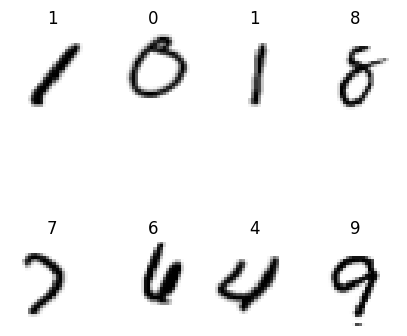

In [37]:
random_shift_model = tf.keras.Sequential([
    tf.keras.layers.RandomTranslation(0.1, 0.1)
])
plt.figure(figsize=(5, 5))
for (x, y) in train.take(1):
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(random_shift_model(x[i]), cmap="binary")
        plt.title(y[i].numpy())
        plt.axis("off")


In [38]:
tf.maximum(tf.math.floordiv(1, 16), 1)

<tf.Tensor: shape=(), dtype=int32, numpy=1>

In [39]:
class SqueezeExciteLayer(tf.keras.layers.Layer):
    # Only works with 16+ filters
    def __init__(self, filters, **kwargs):
        super().__init__(**kwargs)

        layer1_units = max(1, filters // 16)

        self.layers = [
            tf.keras.layers.GlobalAvgPool2D(),
            # tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(layer1_units, activation="relu", kernel_initializer="he_normal"),
            tf.keras.layers.Dense(filters, activation="sigmoid"),
            tf.keras.layers.Reshape([1, 1, filters])
        ]

    # @tf.function
    def call(self, inputs):
        Z = inputs
        for layer in self.layers:
            Z = layer(Z)
        return Z

class FastSE(tf.keras.layers.Layer):
    def __init__(self, filters, **kwargs):
        super().__init__(**kwargs)

        reduced = max(1, filters // 16)

        self.pool = tf.keras.layers.GlobalAveragePooling2D(keepdims=True)

        self.conv1 = tf.keras.layers.Conv2D(
            reduced, 1, activation="relu", kernel_initializer="he_normal"
        )

        self.conv2 = tf.keras.layers.Conv2D(
            filters, 1, activation="sigmoid"
        )

    def call(self, x):
        s = self.pool(x)
        s = self.conv1(s)
        s = self.conv2(s)
        return s

In [40]:
se = SqueezeExciteLayer(3)

In [41]:
example = tf.cast(tf.constant([[[[1, 1, 1],
                        [1, 1, 1]],
                       [[1, 1, 1],
                        [1, 1, 1]]]]),
                  dtype=tf.float32)
example.shape

TensorShape([1, 2, 2, 3])

In [42]:
se(example).shape

TensorShape([1, 1, 1, 3])

In [43]:
tf.multiply(se(example), example)

<tf.Tensor: shape=(1, 2, 2, 3), dtype=float32, numpy=
array([[[[0.9569931 , 0.80791193, 0.417086  ],
         [0.9569931 , 0.80791193, 0.417086  ]],

        [[0.9569931 , 0.80791193, 0.417086  ],
         [0.9569931 , 0.80791193, 0.417086  ]]]], dtype=float32)>

creating my skip unit layer:

In [44]:
class ResidualLayerWithSE(tf.keras.layers.Layer):
    def __init__(self, filters, kernel_size, strides=1, **kwargs):
        # change strides if number of filters differ from previous layer
        super().__init__(**kwargs)

        self.layers = [
            tf.keras.layers.SeparableConv2D(filters=filters, kernel_size=kernel_size, strides=strides, padding="same", depthwise_initializer="he_normal", pointwise_initializer="he_normal"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation("relu"),
            tf.keras.layers.SeparableConv2D(filters=filters, kernel_size=kernel_size, strides=1, padding="same", depthwise_initializer="he_normal", pointwise_initializer="he_normal"),
            tf.keras.layers.BatchNormalization()
        ]
        self.skips = []
        if strides > 1:
            self.skips.append(tf.keras.layers.SeparableConv2D(filters=filters, kernel_size=1, strides=strides, padding="same", depthwise_initializer="he_normal", pointwise_initializer="he_normal"))
            self.skips.append(tf.keras.layers.BatchNormalization())

        self.relu = tf.keras.layers.Activation("relu")

        self.squeeze_excite = SqueezeExciteLayer(filters)

    # @tf.function
    def call(self, inputs):
        Z = inputs
        for layer in self.layers:
            Z = layer(Z)

        Z_se = self.squeeze_excite(Z)

        Z_skip = inputs
        for layer in self.skips:
            Z_skip = layer(Z_skip)

        return self.relu(Z * Z_se + Z_skip)


In [45]:
for x, y in train.take(1):
    example = x[:2]
print(example.shape)
layer = ResidualLayerWithSE(filters=1, kernel_size=3)
layer(norm_layer(example))

(2, 28, 28, 1)


<tf.Tensor: shape=(2, 28, 28, 1), dtype=float32, numpy=
array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
      

In [46]:
se = SqueezeExciteLayer(filters=1)
se(norm_layer(example)).shape

TensorShape([2, 1, 1, 1])

`check augmentation code on book (trainable true to work?)`

augmentation (translation), preprocess, 1 conv, LRN, pool, 1 conv, LRN, pool, skip depthwise + SE (with BN), skip_depthwise + SE, dense, BN, dropout, dense, BN, dropout, output

In [47]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[28, 28, 1]),
    norm_layer, # preprocess
    tf.keras.layers.RandomTranslation(0.1, 0.1), # small augmentation
    tf.keras.layers.Conv2D(filters=32, kernel_size=5, strides=2, padding="same", kernel_initializer="he_normal"), # 2 layers of normal convolution with BN
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Lambda(tf.nn.local_response_normalization, arguments=dict(bias=2, beta=0.75, alpha=0.001)), # LRN
    tf.keras.layers.Conv2D(filters=64, kernel_size=3, strides=1, padding="same", kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Lambda(tf.nn.local_response_normalization, arguments=dict(bias=2, beta=0.75, alpha=0.001)),
    ResidualLayerWithSE(filters=64, kernel_size=3), # Residual units using depthwise separable convolution layers with squeeze and excite module
    tf.keras.layers.MaxPool2D(),
    ResidualLayerWithSE(filters=128, kernel_size=3, strides=2),
    tf.keras.layers.GlobalAvgPool2D(),
    # tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(32, kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation="softmax"),
])

optimizer = tf.keras.optimizers.Nadam(1e-4)

model.compile(loss="sparse_categorical_crossentropy",
              metrics=["accuracy"],
              optimizer=optimizer)

In [48]:
early_stop_cb = tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)

history = model.fit(train, validation_data=valid, epochs=100, callbacks=[early_stop_cb], batch_size=128)

Epoch 1/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.1480 - loss: 2.5852 - val_accuracy: 0.2174 - val_loss: 2.0534
Epoch 2/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.3153 - loss: 1.9518 - val_accuracy: 0.7006 - val_loss: 1.3022
Epoch 3/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.4577 - loss: 1.5886 - val_accuracy: 0.8156 - val_loss: 1.0093
Epoch 4/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.5819 - loss: 1.3003 - val_accuracy: 0.8998 - val_loss: 0.7301
Epoch 5/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.6791 - loss: 1.0651 - val_accuracy: 0.9294 - val_loss: 0.5426
Epoch 6/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7417 - loss: 0.8992 - val_accuracy: 0.9436 - val_loss: 0.3973
Epoch 7/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7824 - loss: 0.7655 - val_accuracy: 0.9546 - val_loss: 0.3013
Epoch 8/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8162 - loss: 0

In [49]:
model.evaluate(test)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9922 - loss: 0.0344


[0.03270576521754265, 0.9923999905586243]

99% Accuracy !!!!!!!!!!!!!!!!

## 10.  Use transfer learning for large image classification

_Exercise: Use transfer learning for large image classification, going through these steps:_

* _Create a training set containing at least 100 images per class. For example, you could classify your own pictures based on the location (beach, mountain, city, etc.), or alternatively you can use an existing dataset (e.g., from TensorFlow Datasets)._
* _Split it into a training set, a validation set, and a test set._
* _Build the input pipeline, including the appropriate preprocessing operations, and optionally add data augmentation._
* _Fine-tune a pretrained model on this dataset._

In [50]:
import tensorflow_datasets as tfds

train_raw, valid_raw, test_raw = tfds.load("cifar10", split=["train[:45000]", "train[45000:]", "test"], as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.BIS1B5_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.BIS1B5_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.


In [51]:
base_model = tf.keras.applications.ResNet101V2(
    include_top=False,
    weights="imagenet",
    input_shape=[32,32,3],
    pooling="avg"
)

preprocess = tf.keras.applications.resnet_v2.preprocess_input

171317808/171317808 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [52]:
preprocess_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[32, 32, 3]),
    tf.keras.layers.Lambda(preprocess)
])

In [53]:
batch_size = 32
train = train_raw.cache().shuffle(45_000, reshuffle_each_iteration=True).batch(batch_size, num_parallel_calls=tf.data.AUTOTUNE, deterministic=False).map(lambda X, y: (preprocess_model(X), y), num_parallel_calls=tf.data.AUTOTUNE, deterministic=False).prefetch(tf.data.AUTOTUNE)
valid = valid_raw.batch(batch_size, num_parallel_calls=tf.data.AUTOTUNE, deterministic=False).map(lambda X, y: (preprocess_model(X), y), num_parallel_calls=tf.data.AUTOTUNE, deterministic=False).cache().prefetch(tf.data.AUTOTUNE)
test = test_raw.batch(batch_size, num_parallel_calls=tf.data.AUTOTUNE, deterministic=False).map(lambda X, y: (preprocess_model(X), y), num_parallel_calls=tf.data.AUTOTUNE, deterministic=False).cache().prefetch(tf.data.AUTOTUNE)

In [54]:
dense1_layer = tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal")
batch_norm_layer = tf.keras.layers.BatchNormalization()
dropout_layer = tf.keras.layers.Dropout(0.5)
output_layer = tf.keras.layers.Dense(10, activation="softmax")

dense1 = dense1_layer(base_model.output)
batch_norm = batch_norm_layer(dense1)
dropout = dropout_layer(batch_norm)
output = output_layer(dropout)
model = tf.keras.Model(inputs=base_model.input, outputs=output)

for layer in base_model.layers:
    layer.trainable = False

optimizer = tf.keras.optimizers.SGD(1e-1, momentum=0.9)

model.compile(loss="sparse_categorical_crossentropy",
              metrics=["accuracy"],
              optimizer=optimizer)

early_stop_cb = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

model.fit(train, validation_data=valid, epochs=10, callbacks=[early_stop_cb])

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 54s 23ms/step - accuracy: 0.2029 - loss: 2.3095 - val_accuracy: 0.3106 - val_loss: 1.9543
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.2639 - loss: 2.0349 - val_accuracy: 0.3208 - val_loss: 1.9031
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.2924 - loss: 1.9816 - val_accuracy: 0.3430 - val_loss: 1.8465
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.3022 - loss: 1.9495 - val_accuracy: 0.3610 - val_loss: 1.8205
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.3125 - loss: 1.9346 - val_accuracy: 0.3222 - val_loss: 1.8586
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.3191 - loss: 1.9225 - val_accuracy: 0.3304 - val_loss: 1.8629
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.3286 - loss: 1.9078 - val_accuracy: 0.3404 - val_loss: 1.8459
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.3214 - lo

In [55]:
model.evaluate(test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.3705 - loss: 1.7648


[1.781644582748413, 0.3684999942779541]

In [56]:
len(base_model.layers)

378

In [57]:
for indices in zip(range(126), range(126, 252), range(252, 378)):
    for idx in indices:
        print(f"{idx:3}: {base_model.layers[idx].name:25}", end="")
    print()

  0: input_layer_9            126: conv4_block4_2_conv      252: conv4_block16_preact_bn  
  1: conv1_pad                127: conv4_block4_2_bn        253: conv4_block16_preact_relu
  2: conv1_conv               128: conv4_block4_2_relu      254: conv4_block16_1_conv     
  3: pool1_pad                129: conv4_block4_3_conv      255: conv4_block16_1_bn       
  4: pool1_pool               130: conv4_block4_out         256: conv4_block16_1_relu     
  5: conv2_block1_preact_bn   131: conv4_block5_preact_bn   257: conv4_block16_2_pad      
  6: conv2_block1_preact_relu 132: conv4_block5_preact_relu 258: conv4_block16_2_conv     
  7: conv2_block1_1_conv      133: conv4_block5_1_conv      259: conv4_block16_2_bn       
  8: conv2_block1_1_bn        134: conv4_block5_1_bn        260: conv4_block16_2_relu     
  9: conv2_block1_1_relu      135: conv4_block5_1_relu      261: conv4_block16_3_conv     
 10: conv2_block1_2_pad       136: conv4_block5_2_pad       262: conv4_block16_out        

In [58]:
for layer in base_model.layers[208:]:
    layer.trainable = True

optimizer = tf.keras.optimizers.SGD(1e-2, momentum=0.9)

model.compile(loss="sparse_categorical_crossentropy",
              metrics=["accuracy"],
              optimizer=optimizer)

early_stop_cb = tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)

model.fit(train, validation_data=valid, epochs=20, callbacks=[early_stop_cb])

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 78s 32ms/step - accuracy: 0.1117 - loss: 2.3335 - val_accuracy: 0.1354 - val_loss: 2.2309
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.1526 - loss: 2.1906 - val_accuracy: 0.2548 - val_loss: 1.8318
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.2566 - loss: 1.8495 - val_accuracy: 0.2972 - val_loss: 1.7609
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.3410 - loss: 1.6816 - val_accuracy: 0.4562 - val_loss: 1.4976
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.4287 - loss: 1.5761 - val_accuracy: 0.5158 - val_loss: 1.3179
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.4709 - loss: 1.4905 - val_accuracy: 0.5646 - val_loss: 1.2072
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.5416 - loss: 1.2949 - val_accuracy: 0.5744 - val_loss: 1.1995
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.5794 -

In [59]:
model.evaluate(test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7015 - loss: 0.8947


[0.9248947501182556, 0.692799985408783]

Yikes! Maybe I should just train the entire model. It would take very long though.

# Author's answers

The following model uses 2 convolutional layers, followed by 1 pooling layer, then dropout 25%, then a dense layer, another dropout layer but with 50% dropout, and finally the output layer. It reaches about 99.2% accuracy on the test set. This places this model roughly in the top 20% in the [MNIST Kaggle competition](https://www.kaggle.com/c/digit-recognizer/) (if we ignore the models with an accuracy greater than 99.79% which were most likely trained on the test set, as explained by Chris Deotte in [this post](https://www.kaggle.com/c/digit-recognizer/discussion/61480)). Can you do better? To reach 99.5 to 99.7% accuracy on the test set, you need to add image augmentation, batch norm, use a learning schedule such as 1-cycle, and possibly create an ensemble.

In [60]:
mnist = tf.keras.datasets.mnist.load_data()

(X_train_full, y_train_full), (X_test, y_test) = mnist
X_train_full = X_train_full / 255.
X_test = X_test / 255.
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test = X_test[..., np.newaxis]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [63]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, kernel_size=3, padding="same",
                           activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Conv2D(64, kernel_size=3, padding="same",
                           activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(128, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])

model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))
model.evaluate(X_test, y_test)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.8787 - loss: 0.3956 - val_accuracy: 0.9858 - val_loss: 0.0507
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9721 - loss: 0.0946 - val_accuracy: 0.9876 - val_loss: 0.0466
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9807 - loss: 0.0641 - val_accuracy: 0.9902 - val_loss: 0.0370
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9829 - loss: 0.0548 - val_accuracy: 0.9920 - val_loss: 0.0344
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9870 - loss: 0.0436 - val_accuracy: 0.9918 - val_loss: 0.0338
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9892 - loss: 0.0351 - val_accuracy: 0.9920 - val_loss: 0.0341
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9897 - loss: 0.0325 - val_accuracy: 0.9908 - val_loss: 0.0403
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9914 - loss: 0.0275 -

[0.04372599348425865, 0.9904000163078308]

## 10.  Use transfer learning for large image classification

_Exercise: Use transfer learning for large image classification, going through these steps:_

* _Create a training set containing at least 100 images per class. For example, you could classify your own pictures based on the location (beach, mountain, city, etc.), or alternatively you can use an existing dataset (e.g., from TensorFlow Datasets)._
* _Split it into a training set, a validation set, and a test set._
* _Build the input pipeline, including the appropriate preprocessing operations, and optionally add data augmentation._
* _Fine-tune a pretrained model on this dataset._

See the Flowers example above.